# Attention Is All You Need


_This notebook is pre solved, and demonstrates the implementation of Transformers architecture proposed by [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762) for neural machine translation (NMT)._

Let's focus on understanding attention mechanisms today.

> _Sequence-to-sequence models are deep learning models that have achieved a lot of success in tasks like machine translation, text summarization, and image captioning. Google Translate started [using](https://blog.google/products/translate/found-translation-more-accurate-fluent-sentences-google-translate/) such a model in production in late 2016. These models are explained in the two pioneering papers ([Sutskever et al., 2014](https://papers.nips.cc/paper/5346-sequence-to-sequence-learning-with-neural-networks.pdf), [Cho et al., 2014](http://emnlp2014.org/papers/pdf/EMNLP2014179.pdf)). (Excerpt from a [blog post](https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/) by Jay Alammar)_

Sequence-to-sequence (aka seq2seq) model is an end-to-end deep learning model which transforms one sequence to another. It consists of two recurrent neural networks:
- encoder, which encodes an input sequence of variable size into a context vector of fixed size
- decoder, which unfolds the context vector into a new sequence (output).


![seq2seq model](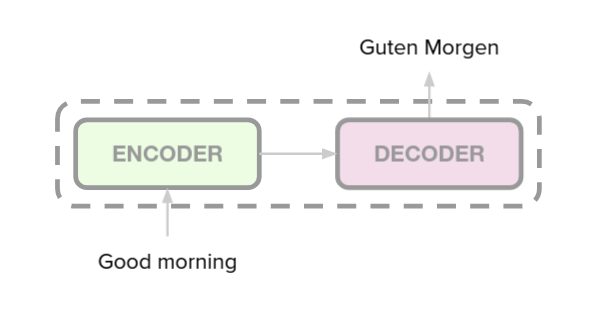 "Seq2Seq Model")


Seq2Seq NMT model can be thought of autoregressive language model where the decoder finds the target sequence that is the most probable conditioned on the input sequence. Mathematically, it can be formulated as follows:

$$
P(y|x) = P(y_1|x) P(y_2|y_1,x) \dots P(y_T|y_1, \dots, y_{T-1}, x)
$$

where $x$ is the input sequence and $y$ is the output sequence.


Attention mechanism have overcomed the drawback of vanilla seq2seq models by providing us a way to see different parts of encoder outputs during the decoding stage, which allows us to preserve the context. The attention mechanim between encoder and decoder resulted in performance improvements for machine translation task.

Transformer are a class of deep learning models which does not use any recurrence. Instead they use self-attention mechanism for representations to find global dependencies between input and target. Transformers have become the de facto standard in NLP and have achieved state-of-the-art performance for various tasks. The Transformer is behind all the popular language models such as BERT, GPT, etc.


We will build a Transformer model for English to German translation using PyTorch.


In [11]:
%%capture
# download the spacy language models for english and german
!python -m spacy download en --quiet
!python -m spacy download de --quiet

In [12]:
!pip install -q datasets

In [7]:
%%capture
!pip install -q torchtext==0.6.0

In [8]:
!pip uninstall -y torchtext
!pip install torchtext==0.11.2

Found existing installation: torchtext 0.6.0
Uninstalling torchtext-0.6.0:
  Successfully uninstalled torchtext-0.6.0
ERROR: Could not find a version that satisfies the requirement torchtext==0.11.2 (from versions: 0.1.1, 0.2.0, 0.2.1, 0.2.3, 0.3.1, 0.4.0, 0.5.0, 0.6.0, 0.16.2, 0.17.2, 0.18.0)
ERROR: No matching distribution found for torchtext==0.11.2


In [9]:
import torch
import torchtext

print("Python:", __import__("sys").version)
print("PyTorch:", torch.__version__)
print("TorchText:", torchtext.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.2.2+cu121
TorchText: 0.6.0


In [14]:
import math
import random
import numpy as np
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import spacy

import warnings
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)

PyTorch: 2.2.2+cu121


## Imports


In [16]:
# plot style configuration
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

rcParams['figure.figsize'] = 12, 8

In [17]:
# for reproducibility
# refer https://pytorch.org/docs/stable/notes/randomness.html
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data Preprocessing and Loading


### Spacy


In [18]:
import spacy

# Load a pre-trained English model
nlp = spacy.load("en_core_web_sm")

# Process some text
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")

# Named Entity Recognition
for ent in doc.ents:
    print(ent.text, ent.label_)


Apple ORG
U.K. GPE
$1 billion MONEY




| Text            | Label | Meaning                                                                 |
|-----------------|-------|-------------------------------------------------------------------------|
| **Apple**       | ORG   | **Organization** — spaCy recognized 'Apple' as a company name           |
| **U.K.**        | GPE   | **Geo-Political Entity** — a country, city, or state (United Kingdom)    |
| **$1 billion**  | MONEY | **Monetary Value** — amount of money mentioned in the text              |

---

In spaCy's pipeline, after tokenizing and parsing the sentence, **Named Entity Recognition (NER)** identifies specific types of real-world objects **(entities)** inside the text and assigns **labels** to them.

So:

- **Apple** → correctly identified as a **company** (Organization)
- **U.K.** → correctly identified as a **country** (Geo-political entity)
- **$1 billion** → correctly identified as a **money amount**


Now that we know what Spacy does, let's get back to the Notebook

In [20]:
# Load English and German spaCy models
spacy_en = spacy.load("en_core_web_sm")
spacy_de = spacy.load("de_core_news_sm")


def tokenize_en(text):
    """Tokenize an English text sequence into a list of tokens."""
    return [token.text for token in spacy_en.tokenizer(text)]


def tokenize_de(text):
    """Tokenize a German text sequence into a list of tokens."""
    return [token.text for token in spacy_de.tokenizer(text)]


# Special tokens
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

print("English tokenizer: OK")
print("German tokenizer: OK")

English tokenizer: OK
German tokenizer: OK


In [22]:
from datasets import load_dataset

# Load Multi30k English-German dataset
dataset = load_dataset("bentrevett/multi30k")

# Split the dataset
train_data = dataset["train"]
valid_data = dataset["validation"]
test_data = dataset["test"]

# Display dataset information
print(dataset)

print("\nTraining examples:", len(train_data))
print("Validation examples:", len(valid_data))
print("Test examples:", len(test_data))

print("\nFirst training example:")
print(train_data[0])

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/4.60M [00:00<?, ?B/s]

val.jsonl:   0%|          | 0.00/164k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/156k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

Training examples: 29000
Validation examples: 1014
Test examples: 1000

First training example:
{'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}


In [24]:
from collections import Counter


def build_vocab(dataset, language, max_size=10000, min_freq=2):
    """
    Build a vocabulary from the training dataset.

    language:
        "en" for English
        "de" for German
    """

    counter = Counter()

    for example in dataset:
        if language == "en":
            text = example["en"]
        else:
            text = example["de"]

        tokens = tokenize_en(text) if language == "en" else tokenize_de(text)

        counter.update(token.lower() for token in tokens)

    # Special tokens
    special_tokens = [
        UNK_TOKEN,
        PAD_TOKEN,
        SOS_TOKEN,
        EOS_TOKEN,
    ]

    # Keep words meeting the minimum frequency
    words = [
        word for word, freq in counter.most_common()
        if freq >= min_freq
    ]

    # Limit vocabulary size
    words = words[:max_size - len(special_tokens)]

    # Create token-to-index and index-to-token mappings
    stoi = {
        token: index
        for index, token in enumerate(special_tokens + words)
    }

    itos = [token for token in special_tokens + words]

    return {
        "stoi": stoi,
        "itos": itos,
        "freqs": counter,
    }


# Build English vocabulary
en_vocab = build_vocab(
    train_data,
    language="en",
    max_size=10000,
    min_freq=2
)

# Build German vocabulary
de_vocab = build_vocab(
    train_data,
    language="de",
    max_size=10000,
    min_freq=2
)


print("English vocabulary size:", len(en_vocab["itos"]))
print("German vocabulary size:", len(de_vocab["itos"]))

English vocabulary size: 5893
German vocabulary size: 7853


In [26]:
PAD_IDX = de_vocab["stoi"][PAD_TOKEN]
SOS_IDX = de_vocab["stoi"][SOS_TOKEN]
EOS_IDX = de_vocab["stoi"][EOS_TOKEN]
UNK_IDX = de_vocab["stoi"][UNK_TOKEN]

print(f"English vocabulary: {len(en_vocab['itos'])} words")
print(f"German vocabulary: {len(de_vocab['itos'])} words")

English vocabulary: 5893 words
German vocabulary: 7853 words


In [28]:
print(f"# of training examples: {len(train_data)}")
print(f"# of validation examples: {len(valid_data)}")
print(f"# of testing examples: {len(test_data)}")

print(train_data[0].keys())
print(train_data[0].values())

# of training examples: 29000
# of validation examples: 1014
# of testing examples: 1000
dict_keys(['en', 'de'])
dict_values(['Two young, White males are outside near many bushes.', 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'])


In [30]:
BATCH_SIZE = 64

# Create PyTorch DataLoaders
from torch.utils.data import DataLoader

train_iterator = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_iterator = DataLoader(
    valid_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_iterator = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [32]:
# Sanity check to see if data loader is working

x = next(iter(train_iterator))

print("Batch keys:", x.keys())
print("First example:")
print(x)

Batch keys: dict_keys(['en', 'de'])
First example:
{'en': ['A man shows a large hammer.', 'A man in a tan jacket and blue jeans is sitting on a bench playing the guitar, with another man close-by.', 'A worker wearing a bright vest and black clothes is picking up trash on the ground while people cross the street behind him.', 'A man wearing a black helmet, blue jacket, and khaki shirts rides his bike on the street next to a red car.', 'Two bikers a riding along a street in a marathon as the passersby clap for them.', 'A dog running at the shore of a lake, hill in the background.', 'Two men are wrestling while other people are watching', 'A band plays in a bar setting', 'Indian students working and in discussion in a classroom.', 'A small brown dog is playing with a fuzzy slipper.', 'A swimmer swimming across a lap pool.', "A teacher is fixing a little student's hair.", 'These young ladies are sitting comfortable discussing their food or talking about the woman.', 'A man on an elevator l

## Model Architecture


![transformer_model](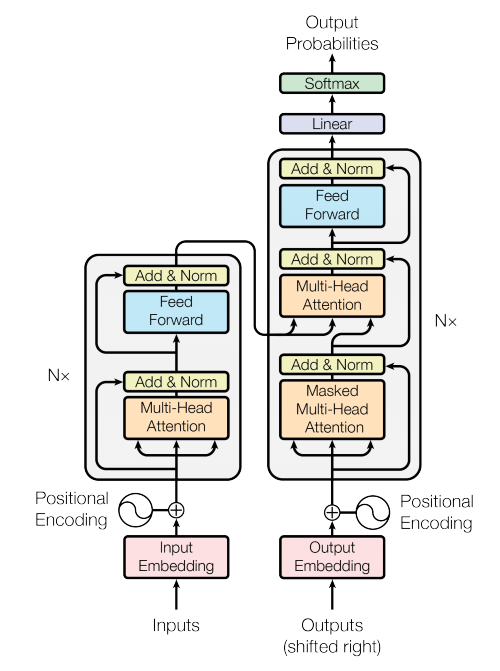 "Transformer Model")

(source: https://arxiv.org/pdf/1706.03762.pdf)


### Scaled Dot-Product Attention


![scaled_dot_product_attention](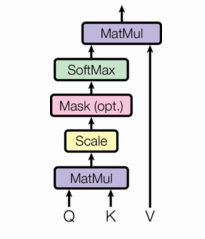 "Scaled Dot-Product Attention Block")

(source: https://arxiv.org/pdf/1706.03762.pdf)


> _An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key. (Excerpt from [Attention is All You Need paper](https://arxiv.org/pdf/1706.03762.pdf))_

The Transformer uses scaled dot-production attention as a self-attention block to compute the representations by taking the dot product of the query matrix $Q$ and the key matrix $K$ scaled by square root of head dimension ($\sqrt{d_k}$) followed by applying softmax and multiplying the values matrix $V$.

$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{Q K^T}{\sqrt{d_k}}) V
$$

The scaled dot-product attention is similar to standard dot-product (multiplicative) attention except that we use a scaling factor $\sqrt{d_k}$ in order to avoid extremely small gradients.

Scaled Dot-Product Attention returns the following:
- `output`: weighted sum of the values (self-attention representations) w.r.t alignment scores
- `attn_probs`: alignment scores indicating how well values around position $i$ match with values around position $j$


In [33]:
class ScaledDotProductAttention(nn.Module):
    """ Computes scaled dot product attention
    """

    def __init__(self, scale, dropout_rate):
        super(ScaledDotProductAttention, self).__init__()
        self.scale = scale
        self.dropout_rate = dropout_rate

        self.dropout = nn.Dropout(dropout_rate)


    def forward(self, query, key, value, mask=None):
        """ query: (batch_size, n_heads, query_len, head_dim)
            key: (batch_size, n_heads, key_len, head_dim)
            value: (batch_size, n_heads, value_len, head_dim)
            mask: (batch_size, 1, 1, source_seq_len) for source mask
                  (batch_size, 1, target_seq_len, target_seq_len) for target mask
        """
        # calculate alignment scores
        scores = torch.matmul(query, key.transpose(-2, -1))  # (batch_size, n_heads, query_len, value_len)
        scores = scores / self.scale  # (batch_size, num_heads, query_len, value_len)

        # mask out invalid positions
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))  # (batch_size, n_heads, query_len, value_len)

        # calculate the attention weights (prob) from alignment scores
        attn_probs = F.softmax(scores, dim=-1)  # (batch_size, n_heads, query_len, value_len)

        # calculate context vector
        output = torch.matmul(self.dropout(attn_probs), value)  # (batch_size, n_heads, query_len, head_dim)

        # output: (batch_size, n_heads, query_len, head_dim)
        # attn_probs: (batch_size, n_heads, query_len, value_len)
        return output, attn_probs

### Multi-Head Attention Module


![multi_head_attention](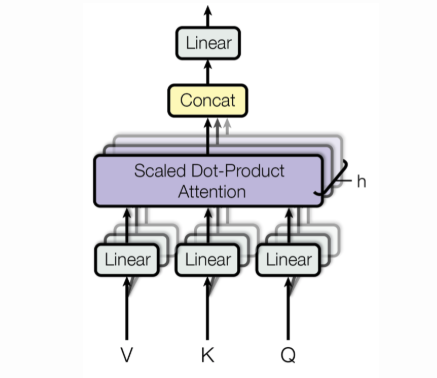 "Multi-Head Attention Block")

(source: https://arxiv.org/pdf/1706.03762.pdf)


Instead of using single self-attention layer, the authors introduced multi-head attention mechanism which simply performs multiple scaled dot-product attention computations in parallel. The authors split queries, keys and values with $d_{model}$ dimension into $h$ heads and then re-combine scaled dot-product computation over each head into a single vector with $d_model$ dimension.

> _Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. (Excerpt from [Attention is All You Need paper](https://arxiv.org/pdf/1706.03762.pdf))_

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O \\
\text{where}\ \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V) \\
W_i^Q \in \mathbb{R}^{\mathrm{d_{model}\times d_k}}, W_i^K \in \mathbb{R}^{\mathrm{d_{model}\times d_k}}, W_i^V \in \mathbb{R}^{\mathrm{d_{model}\times d_v}}, W_i^O \in \mathbb{R}^{\mathrm{hd_v\times d_{model}}}
$$

First, the inputs: query matrix $Q$, key matrix $K$ and value matrix $V$ are linearly projected using $W^Q$, $W^K$ and $W^V$. The projected query $QW^Q$, key $KW^K$ and value $VW^V$ are split into $h$ heads. Scaled dot-product attention is computed for each head $i$. The independent attention head computed are then concatenated and linearly projected using $W^O$.

Multi-Head Attention returns the following:
- `x`: context vector concatenated over all the attention heads
- `attn`: alignment scores (attention weights) over all the attention heads


In [34]:
class MultiHeadAttention(nn.Module):
    """ Implements Multi-Head Self-Attention proposed by Vaswani et al., 2017.
        refer https://arxiv.org/abs/1706.03762
    """

    def __init__(self, d_model, n_heads, dropout_rate=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % n_heads == 0, "`d_model` should be a multiple of `n_heads`"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = self.d_v = d_model // n_heads  # head_dim
        self.dropout_rate = dropout_rate

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(np.sqrt(self.d_k), dropout_rate)


    def split_heads(self, x):
        """ x: (batch_size, seq_len, d_model)
        """
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)  # (batch_size, n_heads, seq_len, d_k)

        # x: (batch_size, n_heads, seq_len, head_dim)
        return x


    def group_heads(self, x):
        """ x: (batch_size, n_heads, seq_len, head_dim)
        """
        batch_size = x.size(0)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.n_heads * self.d_k)

        # x: (batch_size, seq_len, d_model)
        return x


    def forward(self, query, key, value, mask=None):
        """ query: (batch_size, query_len, d_model)
            key: (batch_size, key_len, d_model)
            value: (batch_size, value_len, d_model)
            mask: (batch_size, 1, source_seq_len) for source mask
                  (batch_size, target_seq_len, target_seq_len) for target mask
        """
        # apply linear projections to query, key and value
        Q = self.split_heads(self.W_q(query))  # (batch_size, n_heads, query_len, head_dim)
        K = self.split_heads(self.W_k(key))  # (batch_size, n_heads, key_len, head_dim)
        V = self.split_heads(self.W_v(value))  # (batch_size, n_heads, value_len, head_dim)

        if mask is not None:
            # apply same mask for all the heads
            mask = mask.unsqueeze(1)

            # mask: (batch_size, 1, 1, source_seq_len) for source mask
            #       (batch_size, 1, target_seq_len, target_seq_len) for target mask

        # calculate attention weights and context vector for each of the heads
        x, attn = self.attention(Q, K, V, mask)

        # x: (batch_size, n_heads, query_len, head_dim)
        # attn: (batch_size, n_heads, query_len, value_len)

        # concatenate context vector of all the heads
        x = self.group_heads(x)  # (batch_size, query_len, d_model)

        # apply linear projection to concatenated context vector
        x = self.W_o(x)  # (batch_size, query_len, d_model)

        # x: (batch_size, query_len, d_model)
        # attn: (batch_size, n_heads, query_len, value_len)
        return x, attn

### Position-wise Feed-Forward Network Module


This is the another block in the encoder as well as decoder layer which transforms from $d_{model}$ to $d_{ff}$ and then again to $d_{model}$. The same linear transformation is applied across different positions. This can also be viewed as two convolutions with filter size 1.

$$
FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
$$

Position-wise Feed-Forward Network returns the following:
- `x`: non-linearity transformed vector of dimension same as input


In [35]:
class PositionwiseFeedForward(nn.Module):
    """ Implements a two layer feed-forward network.
    """

    def __init__(self, d_model, d_ff, dropout_rate=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout_rate)


    def forward(self, x):
        """ x: (batch_size, seq_len, d_model)
        """
        x = self.dropout(F.relu(self.w_1(x)))  # (batch_size, seq_len, d_ff)
        x = self.w_2(x)  # (batch_size, seq_len, d_model)

        # x: (batch_size, seq_len, d_model)
        return x

### Positional Encoding Module


Since the transformer contains no recurrence and no convolutions, we need some way to inject information about relative or absolute position to assign order to tokens in the sequence. Sinusoidal positional encodings are used with different frequencies to unique represent the order and the position of the token in sequence.

$$
\begin{aligned}
\text{PE}_{(pos, 2i)} &= \text{sin}(\frac{pos}{10000^{2i/d_{model}}}) \\
\text{PE}_{(pos, 2i + 1)} &= \text{cos}(\frac{pos}{10000^{2i/d_{model}}})
\end{aligned}
$$

where $pos$ is the position and $i$ is the dimension.

> _We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$. (Excerpt from [Attention is All You Need paper](https://arxiv.org/pdf/1706.03762.pdf))_

Positional Encoding Module returns the following:
- `x`: word embedding of the token in the sequence with inherent position information


In [36]:
class PositionalEncoding(nn.Module):
    """ Implements the sinusoidal positional encoding.
    """

    def __init__(self, d_model, dropout_rate=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.dropout_rate = dropout_rate
        self.max_len = max_len

        self.dropout = nn.Dropout(dropout_rate)

        # compute positional encodings
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # (d_model,)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)  # (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """ x: (batch_size, seq_len, d_model)
        """
        x = x + self.pe[:x.size(0), :]  # (batch_size, seq_len, d_model)
        x = self.dropout(x)  # (batch_size, seq_len, d_model)

        # x: (batch_size, seq_len, d_model)
        return x

### Encoder Module


The encoder consists of a stack of $N = 6$ identical layers, each containing two sub-layers, a multi-head self-attention layer, and a position-wise fully connected feed-forward network. Each sub-layer has a residual connection and layer normalization.

Encoder returns the following:
- `x`: encoded sequence representation using self-attention


In [37]:
class EncoderLayer(nn.Module):
    """ Encoder is made up of a self-attention layer and a feed-forward layer.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff
        self.n_heads = n_heads
        self.dropout_rate = dropout_rate

        self.attn_layer = MultiHeadAttention(d_model, n_heads, dropout_rate)
        self.attn_layer_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.ff_layer = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.ff_layer_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout_rate)


    def forward(self, x, mask):
        """ x: (batch_size, source_seq_len, d_model)
            mask: (batch_size, 1, source_seq_len)
        """
        # apply self-attention
        x1, _ = self.attn_layer(x, x, x, mask)  # (batch_size, source_seq_len, d_model)

        # apply residual connection followed by layer normalization
        x = self.attn_layer_norm(x + self.dropout(x1))  # (batch_size, source_seq_len, d_model)

        # apply position-wise feed-forward
        x1 = self.ff_layer(x)  # (batch_size, source_seq_len, d_model)

        # apply residual connection followed by layer normalization
        x = self.ff_layer_norm(x + self.dropout(x1))  # (batch_size, source_seq_len, d_model)

        # x: (batch_size, source_seq_len, d_model)
        return x

In [38]:
class Encoder(nn.Module):
    """ Encoder block is a stack of N identical encoder layers.
    """

    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, pad_idx, dropout_rate=0.1, max_len=5000):
        super(Encoder, self).__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_layers = n_layers
        self.d_ff = d_ff
        self.pad_idx = pad_idx
        self.dropout_rate = dropout_rate
        self.max_len = max_len

        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding = PositionalEncoding(d_model, dropout_rate, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout_rate)
            for _ in range(n_layers)
        ])
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)


    def forward(self, x, mask):
        """ x: (batch_size, source_seq_len)
            mask: (batch_size, 1, source_seq_len)
        """
        # apply positional encoding to token sequences
        x = self.tok_embedding(x)  # (batch_size, source_seq_len, d_model)
        x = self.pos_embedding(x)  # (batch_size, source_seq_len, d_model)

        for layer in self.layers:
            x = layer(x, mask)  # (batch_size, source_seq_len, d_model)

        x = self.layer_norm(x)  # (batch_size, source_seq_len, d_model)

        # x: (batch_size, source_seq_len, d_model)
        return x

### Decoder Module


The decoder is quite similar to the encoder, except that the decoder contains two multi-head self-attention layers instead of a single layer in a stack of $N = 6$ identical layers. The first multi-head self-attention layer attends to decoder outputs generated so far and is masked in order to prevent positions from attending to future positions, whereas the second multi-head self-attention layer attends over the encoder stack output.

Decoder returns the following:
- `x`: output sequence representation using self-attention
- `attn`: alignment scores (attention weights) between input sequence and output sequence


In [39]:
class DecoderLayer(nn.Module):
    """ Decoder is made up of a self-attention layer, a encoder-decoder attention
        layer and a feed-forward layer.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff
        self.n_heads = n_heads
        self.dropout_rate = dropout_rate

        self.attn_layer = MultiHeadAttention(d_model, n_heads, dropout_rate)
        self.attn_layer_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.enc_attn_layer = MultiHeadAttention(d_model, n_heads, dropout_rate)
        self.enc_attn_layer_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.ff_layer = PositionwiseFeedForward(d_model, d_ff, dropout_rate)
        self.ff_layer_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout_rate)


    def forward(self, x, memory, src_mask, tgt_mask):
        """ x: (batch_size, target_seq_len, d_model)
            memory: (batch_size, source_seq_len, d_model)
            src_mask: (batch_size, 1, source_seq_len)
            tgt_mask: (batch_size, target_seq_len, target_seq_len)
        """
        # apply self-attention
        x1, _ = self.attn_layer(x, x, x, tgt_mask)  # (batch_size, target_seq_len, d_model)

        # apply residual connection followed by layer normalization
        x = self.attn_layer_norm(x + self.dropout(x1))  # (batch_size, target_seq_len, d_model)

        # apply encoder-decoder attention
        # memory is the output from encoder block (encoder states)
        x1, attn = self.enc_attn_layer(x, memory, memory, src_mask)

        # x1: (batch_size, target_seq_len, d_model)
        # attn: (batch_size, n_heads, target_seq_len, source_seq_len)

        # apply residual connection followed by layer normalization
        x = self.attn_layer_norm(x + self.dropout(x1))  # (batch_size, target_seq_len, d_model)

        # apply position-wise feed-forward
        x1 = self.ff_layer(x)  # (batch_size, target_seq_len, d_model)

        # apply residual connection followed by layer normalization
        x = self.ff_layer_norm(x + self.dropout(x1))  # (batch_size, target_seq_len, d_model)

        # x: (batch_size, target_seq_len, d_model)
        # attn: (batch_size, n_heads, target_seq_len, source_seq_len)
        return x, attn

In [40]:
class Decoder(nn.Module):
    """ Decoder block is a stack of N identical decoder layers.
    """

    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, pad_idx, dropout_rate=0.1, max_len=5000):
        super(Decoder, self).__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_layers = n_layers
        self.d_ff = d_ff
        self.pad_idx = pad_idx
        self.dropout_rate = dropout_rate
        self.max_len = max_len

        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding = PositionalEncoding(d_model, dropout_rate, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout_rate)
            for _ in range(n_layers)
        ])
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)


    def forward(self, x, memory, src_mask, tgt_mask):
        """ x: (batch_size, target_seq_len, d_model)
            memory: (batch_size, source_seq_len, d_model)
            src_mask: (batch_size, 1, source_seq_len)
            tgt_mask: (batch_size, target_seq_len, target_seq_len)
        """
        # apply positional encoding to token sequences
        x = self.tok_embedding(x)  # (batch_size, target_seq_len, d_model)
        x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

        for layer in self.layers:
            x, attn = layer(x, memory, src_mask, tgt_mask)  # (batch_size, target_seq_len, d_model)

        x = self.layer_norm(x)  # (batch_size, target_seq_len, d_model)

        # x: (batch_size, target_seq_len, d_model)
        # attn: (batch_size, n_heads, target_seq_len, source_seq_len)
        return x, attn

### Transformer


The input and output sequences are embedded into a $d_{model}$ dimensional space, which is the usual step before feeding the sequence into the neural network. Positional encoding is also applied to the embedded sequence, which gives a sense of order in the sequence. Encoder encodes the input sequence and generates encoded representation using self-attention mechanism. The decoder uses this representation along with the sequence generated so far to compute the output sequence.

The Transformer returns the following:
- `output`: output sequence generated
- `attn`: alignment scores (attention weights) between input sequence and output sequence


In [41]:
class Transformer(nn.Module):
    """ Transformer wrapper for encoder and decoder.
    """

    def __init__(self, encoder, decoder, generator, pad_idx):
        super(Transformer, self).__init__()
        self.pad_idx = pad_idx

        self.encoder = encoder
        self.decoder = decoder
        self.generator = generator


    def get_pad_mask(self, x, pad_idx):
        """ x: (batch_size, seq_len)
        """
        x = (x != pad_idx).unsqueeze(-2)  # (batch_size, 1, seq_len)

        # x: (batch_size, 1, seq_len)
        return x


    def get_subsequent_mask(self, x):
        """ x: (batch_size, seq_len)
        """
        seq_len = x.size(1)
        subsequent_mask = np.triu(np.ones((1, seq_len, seq_len)), k=1).astype(np.int8)  # (batch_size, seq_len, seq_len)
        subsequent_mask = (torch.from_numpy(subsequent_mask) == 0).to(x.device)  # (batch_size, seq_len, seq_len)


        # subsequent_mask: (batch_size, seq_len, seq_len)
        return subsequent_mask


    def forward(self, src, tgt):
        """ src: (batch_size, source_seq_len)
            tgt: (batch_size, target_seq_len)
        """
        # create masks for source and target
        src_mask = self.get_pad_mask(src, self.pad_idx)
        tgt_mask = self.get_pad_mask(tgt, self.pad_idx) & self.get_subsequent_mask(tgt)

        # src_mask: (batch_size, 1, seq_len)
        # tgt_mask: (batch_size, seq_len, seq_len)

        # encode the source sequence
        enc_output = self.encoder(src, src_mask)  # (batch_size, source_seq_len, d_model)

        # decode based on source sequence and target sequence generated so far
        dec_output, attn = self.decoder(tgt, enc_output, src_mask, tgt_mask)

        # dec_output: (batch_size, target_seq_len, d_model)
        # attn: (batch_size, n_heads, target_seq_len, source_seq_len)

        # apply linear projection to obtain the output distribution
        output = self.generator(dec_output)  # (batch_size, target_seq_len, vocab_size)

        # output: (batch_size, target_seq_len, vocab_size)
        # attn: (batch_size, n_heads, target_seq_len, source_seq_len)
        return output, attn

In [42]:
class Generator(nn.Module):
    """ Linear projection layer for generating output distribution.
    """

    def __init__(self, d_model, vocab_size):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab_size)


    def forward(self, x):
        """ x: (batch_size, target_seq_len, d_model)
        """
        # apply linear projection followed by softmax to obtain output distribution
        x = self.proj(x)  # (batch_size, target_seq_len, vocab_size)
        output = F.log_softmax(x, dim=-1)  # (batch_size, target_seq_len)

        # output: (batch_size, target_seq_len)
        return output

## Helper Utilities


In [43]:
def model_summary(model):
    print(model)
    print(f'# of trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'# of non-trainable params: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}')

In [44]:
def convert_ids_to_text(ids, vocab, eos_idx, unk_idx):
    """ Converts token ids to text.
    """
    if ids.dim() == 1:
        output_tokens = []
        for token_id in ids:
            if token_id == eos_idx:
                break
            else:
                output_tokens.append(vocab.itos[token_id])
        return output_tokens

    elif ids.dim() == 2:
        return [convert_ids_to_text(ids[i, :], vocab, eos_idx, unk_idx) for i in range(ids.size(0))]

    raise RuntimeError(f'ids has {ids.size()} dimensions, expected 2 dimensions')

In [45]:
class NoamOptim(object):
    """ Optimizer wrapper for learning rate scheduling.
    """

    def __init__(self, optimizer, d_model, factor, n_warmup_steps):
        self.optimizer = optimizer
        self.d_model = d_model
        self.factor = factor
        self.n_warmup_steps = n_warmup_steps
        self.n_steps = 0


    def zero_grad(self):
        self.optimizer.zero_grad()


    def step(self):
        self.n_steps += 1
        lr = self.get_lr()
        for p in self.optimizer.param_groups:
            p['lr'] = lr
        self.optimizer.step()


    def get_lr(self):
        return self.factor * (
            self.d_model ** (-0.5)
            * min(self.n_steps ** (-0.5), self.n_steps * self.n_warmup_steps ** (-1.5))
        )

## Training


In [46]:
def train_fn(model, iterator, optimizer, critertion, clip=1.0):
    model.train()
    total_loss = 0
    steps = 0

    tk0 = tqdm(iterator, total=len(iterator), position=0, leave=True)

    for idx, batch in enumerate(tk0):
        source, source_lengths = batch.src
        target, target_lengths = batch.trg

        # source: (batch_size, source_seq_len), source_lengths: (batch_size)
        # target: (batch_size, target_seq_len), target_lengths: (batch_size)

        # forward pass
        optimizer.zero_grad()
        output, _ = model(source, target[:, :-1])  # (batch_size, target_seq_len - 1, vocab_size)

        # calculate the loss
        loss = criterion(
            output.view(-1, output.size(-1)),  # (batch_size * (target_seq_len - 1), vocab_size)
            target[:, 1:].contiguous().view(-1)  # (batch_size * (target_seq_len - 1))
        )
        total_loss += loss.item()
        steps += 1

        output = output.argmax(dim=-1)  # (batch_size, target_seq_len - 1)

        # backward pass
        loss.backward()

        # clip gradients to avoid exploding gradients issue
        nn.utils.clip_grad_norm_(model.parameters(), clip)

        # update model parameters
        optimizer.step()

        tk0.set_postfix(loss=total_loss/steps)

    tk0.close()

    perplexity = np.exp(total_loss / len(iterator))

    return output, perplexity

In [47]:
def eval_fn(model, iterator, criterion):
    model.eval()
    total_loss = 0.0
    steps = 0
    hypotheses = []
    references = []

    tk0 = tqdm(iterator, total=len(iterator), position=0, leave=True)

    with torch.no_grad():
        for idx, batch in enumerate(tk0):
            source, source_lengths = batch.src
            target, target_lengths = batch.trg

            # source: (batch_size, source_seq_len), source_lengths: (batch_size)
            # target: (batch_size, target_seq_len), target_lengths: (batch_size)

            # forward pass
            optimizer.zero_grad()
            output, _ = model(source, target[:, :-1])  # (batch_size, target_seq_len - 1, vocab_size)

            # calculate the loss
            loss = criterion(
                output.view(-1, output.size(-1)),  # (batch_size * (target_seq_len - 1), vocab_size)
                target[:, 1:].contiguous().view(-1)  # (batch_size * (target_seq_len - 1))
            )
            total_loss += loss.item()
            steps += 1

            output = output.argmax(dim=-1)  # (batch_size, target_seq_len - 1)
            target = target[:, 1:]  # (batch_size, target_seq_len - 1)

            # converting the ids to tokens (used later for calculating BLEU score)
            pred_tokens = convert_ids_to_text(output, de_text.vocab, EOS_IDX, UNK_IDX)
            target_tokens = convert_ids_to_text(target, de_text.vocab, EOS_IDX, UNK_IDX)

            hypotheses += pred_tokens
            references += [[token] for token in target_tokens]

            tk0.set_postfix(loss=total_loss/steps)

    tk0.close()

    perplexity = np.exp(total_loss / len(iterator))
    bleu4 = bleu_score(hypotheses, references)

    return output, perplexity, bleu4

In [49]:
# Hyperparameters

INPUT_SIZE = len(en_vocab["itos"])   # source vocabulary size
OUTPUT_SIZE = len(de_vocab["itos"])  # target vocabulary size

HIDDEN_SIZE = 512
N_LAYERS = 6
N_HEADS = 8
FF_SIZE = 2048
DROPOUT_RATE = 0.1
N_EPOCHS = 10
CLIP = 1.0

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(INPUT_SIZE, HIDDEN_SIZE, N_LAYERS, N_HEADS, FF_SIZE, PAD_IDX, DROPOUT_RATE)
decoder = Decoder(OUTPUT_SIZE, HIDDEN_SIZE, N_LAYERS, N_HEADS, FF_SIZE, PAD_IDX, DROPOUT_RATE)
generator = Generator(HIDDEN_SIZE, OUTPUT_SIZE)

model = Transformer(encoder, decoder, generator, PAD_IDX).to(device)

print(model)

Transformer(
  (encoder): Encoder(
    (tok_embedding): Embedding(5893, 512, padding_idx=1)
    (pos_embedding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (attn_layer): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=False)
          (W_k): Linear(in_features=512, out_features=512, bias=False)
          (W_v): Linear(in_features=512, out_features=512, bias=False)
          (W_o): Linear(in_features=512, out_features=512, bias=True)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (attn_layer_norm): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (ff_layer): PositionwiseFeedForward(
          (w_1): Linear(in_features=512, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inp

In [53]:
optimizer = NoamOptim(
    optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9),
    model.encoder.d_model, 2, 4000
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [54]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [59]:
def train_fn(model, iterator, optimizer, criterion, clip):

    model.train()
    epoch_loss = 0

    tk0 = tqdm(iterator, total=len(iterator), desc="Training")

    for batch in tk0:

        source = batch["en"]
        target = batch["de"]

        optimizer.zero_grad()

        # Convert text to token IDs
        source_tokens = [
            [SOS_IDX] +
            [en_vocab["stoi"].get(token.lower(), UNK_IDX)
             for token in tokenize_en(text)] +
            [EOS_IDX]
            for text in source
        ]

        target_tokens = [
            [SOS_IDX] +
            [de_vocab["stoi"].get(token.lower(), UNK_IDX)
             for token in tokenize_de(text)] +
            [EOS_IDX]
            for text in target
        ]

        # Padding
        max_src_len = max(len(x) for x in source_tokens)
        max_trg_len = max(len(x) for x in target_tokens)

        source_tensor = torch.tensor(
            [
                x + [PAD_IDX] * (max_src_len - len(x))
                for x in source_tokens
            ],
            dtype=torch.long,
            device=device
        )

        target_tensor = torch.tensor(
            [
                x + [PAD_IDX] * (max_trg_len - len(x))
                for x in target_tokens
            ],
            dtype=torch.long,
            device=device
        )

        # Forward pass
        output = model(
            source_tensor,
            target_tensor[:, :-1]
        )

        output_dim = output.shape[-1]

        output = output.contiguous().view(-1, output_dim)
        target = target_tensor[:, 1:].contiguous().view(-1)

        # Loss
        loss = criterion(output, target)

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

        tk0.set_postfix(loss=loss.item())

    epoch_loss /= len(iterator)

    return epoch_loss, math.exp(epoch_loss)

In [62]:
import os

if os.path.exists(model_path):
    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )

    print("Evaluating the model on test data ...")

    _, test_perplexity, test_bleu4 = eval_fn(
        model,
        test_iterator,
        criterion
    )

    print(
        f"Test perplexity: {test_perplexity:.4f}, "
        f"Test BLEU4: {test_bleu4:.4f}"
    )
else:
    print("Error: model.pth was not found.")
    print("The model must be trained successfully before evaluation.")

Error: model.pth was not found.
The model must be trained successfully before evaluation.


## Inference


In [63]:
def greedy_decode(model, sentence, max_len=100):
    model.eval()

    if isinstance(sentence, str):
        tokens = [token.text.lower() for token in spacy_de(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    token_ids = [SOS_IDX] + [en_text.vocab.stoi.get(token, UNK_TOKEN) for token in tokens] + [EOS_IDX]

    source = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, source_seq_len)
    source_mask = model.get_pad_mask(source, PAD_IDX)  # (1, 1, source_seq_len)

    # encode the source sequence
    with torch.no_grad():
        enc_output = model.encoder(source, source_mask)  # (1, source_seq_len, d_model)

    target_ids = [SOS_IDX]

    for i in range(max_len):
        target = torch.tensor(target_ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, target_seq_len)
        target_mask = model.get_pad_mask(target, PAD_IDX) & model.get_subsequent_mask(target)

        # decode the sequence
        with torch.no_grad():
            dec_output, attn = model.decoder(target, enc_output, source_mask, target_mask)

            # dec_output: (1, target_seq_len, d_model)
            # attn: (1, n_heads, target_seq_len, source_seq_len)

            output = model.generator(dec_output)  # (1, target_seq_len, vocab_size)

        target_id = output.argmax(dim=-1)[:, -1].item()
        target_ids.append(target_id)

        # stop decoding if we encounter EOS_TOKEN or reach the max length
        if target_id == EOS_IDX or len(target_ids) >= max_len:
            break

    target_tokens = [de_text.vocab.itos[id] for id in target_ids]
    attn = attn.squeeze(0).cpu().detach().numpy()  # (n_heads, target_seq_len, source_seq_len)

    # target_tokens: list of size (target_seq_len - 1)
    # attn: (n_heads, target_seq_len, source_seq_len)

    return target_tokens[1:], attn

In [64]:
def plot_attention_scores(source, target, attention):
    n_heads = attention.shape[0]

    if isinstance(source, str):
        source = [token.lower for token in source.split(" ")] + [EOS_TOKEN]
    else:
        source = [token.lower() for token in source] + [EOS_TOKEN]

    fig = plt.figure(figsize=(24, 12))

    for h, head in enumerate(attention):
        ax = fig.add_subplot(2, 4, h + 1)
        x = source
        y = target if h % 4 == 0 else []

        sns.heatmap(
            head, xticklabels=x, yticklabels=y, square=True,
            vmin=0.0, vmax=1.0, cbar=False, cmap="Blues", ax=ax,
        )

In [81]:
def plot_attention_scores(source, target, attention):

    if isinstance(attention, list):

        if len(attention) == 0:
            print("No attention scores available.")
            return

        # Use the last decoder attention
        attention = attention[-1]

        # If decoder returns multiple attention tensors
        if isinstance(attention, (tuple, list)):
            attention = attention[-1]

    # Convert to tensor if necessary
    if not torch.is_tensor(attention):
        attention = torch.tensor(attention)

    attention = attention.detach().cpu()

    # Remove unnecessary dimensions
    while attention.dim() > 4:
        attention = attention.squeeze(0)

    # Expected shape:
    # (n_heads, target_len, source_len)
    if attention.dim() == 4:
        attention = attention[0]

    if attention.dim() != 3:
        print("Unexpected attention shape:", attention.shape)
        return

    n_heads = attention.shape[0]

    # Tokenize source
    if isinstance(source, str):
        source_tokens = [
            token.text.lower()
            for token in spacy_en.tokenizer(source)
        ]
    else:
        source_tokens = list(source)

    # Target tokens
    if isinstance(target, str):
        target_tokens = target.split()
    else:
        target_tokens = list(target)

    # Limit to available attention dimensions
    source_tokens = source_tokens[:attention.shape[-1]]
    target_tokens = target_tokens[:attention.shape[-2]]

    fig, axes = plt.subplots(
        n_heads,
        1,
        figsize=(12, 4 * n_heads)
    )

    if n_heads == 1:
        axes = [axes]

    for head in range(n_heads):

        sns.heatmap(
            attention[head, :len(target_tokens), :len(source_tokens)].numpy(),
            xticklabels=source_tokens,
            yticklabels=target_tokens,
            cmap="Blues",
            ax=axes[head]
        )

        axes[head].set_title(f"Attention Head {head + 1}")
        axes[head].set_xlabel("Source")
        axes[head].set_ylabel("Target")

    plt.tight_layout()
    plt.show()

Source : People walking down sidewalk next to a line of stores.
Target : Leute gehen auf einem Gehsteig neben einer Reihe von Geschäften.
Source    : People walking down sidewalk next to a line of stores.
Predicted : weinendes mensch gedruckt bushaltestelle marathonläuferin oranger boy nahost hundes wagens kocht baumstumpf ebene erscheint kocht baumstumpf ebene zerlumpter skilift operiert wasserfontänen röhre schutt marathon bushaltestelle schutt marathon bushaltestelle schutt marathon bushaltestelle schutt marathon bushaltestelle unterstützen flag größeren röhre schutt marathon bushaltestelle unterstützen flag barkeeperin wasserfontänen röhre legt karateturnier teppiche unterstützen


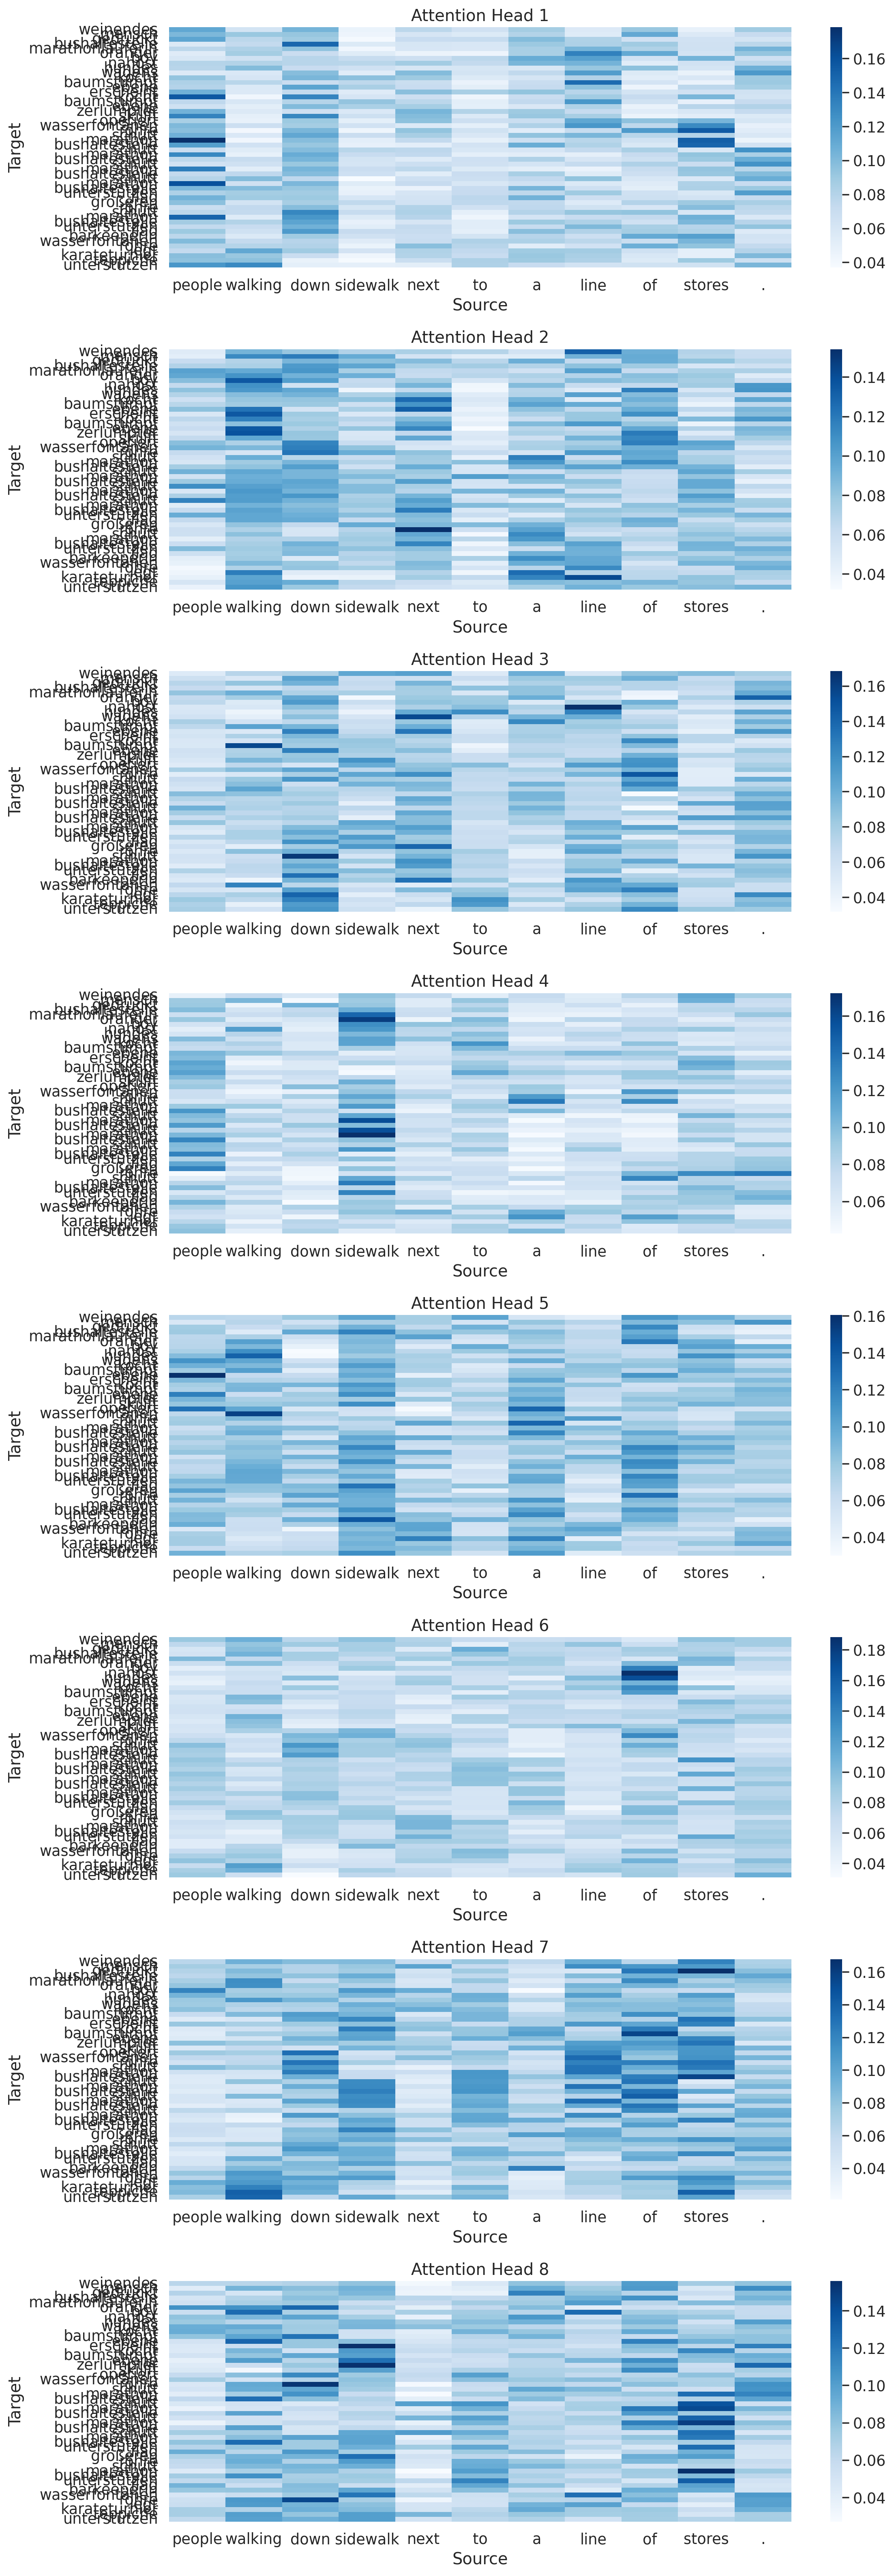

In [82]:
example_idx = 50

source = test_data[example_idx]["en"]
target = test_data[example_idx]["de"]

print("Source :", source)
print("Target :", target)

predicted, attention_scores = greedy_decode(model, source)

plot_attention_scores(
    source,
    predicted,
    attention_scores
)

In [88]:
def greedy_decode(model, sentence, max_len=50):

    model.eval()

    # Tokenize source sentence
    tokens = [token.lower() for token in tokenize_en(sentence)]

    # Convert tokens to IDs
    token_ids = [SOS_IDX] + [
        en_vocab["stoi"].get(token, UNK_IDX)
        for token in tokens
    ] + [EOS_IDX]

    # Source tensor: (1, src_len)
    source = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    # Source mask: (1, 1, 1, src_len)
    src_mask = (
        (source != PAD_IDX)
        .unsqueeze(1)
        .unsqueeze(2)
    )

    # Encode
    with torch.no_grad():
        encoder_output = model.encoder(
            source,
            src_mask
        )

    target_tokens = [SOS_IDX]
    attention_scores = []

    for _ in range(max_len):

        # Target tensor: (1, trg_len)
        target = torch.tensor(
            target_tokens,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        trg_len = target.size(1)

        # Padding mask: (1, 1, 1, trg_len)
        trg_pad_mask = (
            (target != PAD_IDX)
            .unsqueeze(1)
            .unsqueeze(2)
        )

        # Causal mask: (1, 1, trg_len, trg_len)
        causal_mask = torch.tril(
            torch.ones(
                trg_len,
                trg_len,
                dtype=torch.bool,
                device=device
            )
        ).unsqueeze(0).unsqueeze(1)

        # Combined target mask
        trg_mask = trg_pad_mask & causal_mask

        with torch.no_grad():

            decoder_result = model.decoder(
                target,
                encoder_output,
                src_mask,
                trg_mask
            )

            # Handle decoder returning (output, attention)
            if isinstance(decoder_result, tuple):
                output = decoder_result[0]

                if len(decoder_result) > 1:
                    attention_scores.append(
                        decoder_result[1]
                    )
            else:
                output = decoder_result

            # Generate next token
            prediction = model.generator(
                output[:, -1, :]
            )

        next_token = prediction.argmax(
            dim=1
        ).item()

        target_tokens.append(next_token)

        # Stop at EOS
        if next_token == EOS_IDX:
            break

    # Convert IDs to German words
    predicted = [
        de_vocab["itos"][idx]
        for idx in target_tokens[1:]
        if idx not in [EOS_IDX, PAD_IDX]
    ]

    # Print result
    print("Source    :", sentence)
    print("Predicted :", " ".join(predicted))

    return predicted, attention_scores

In [89]:
example_idx = 24

source = valid_data[example_idx]["en"]
target = valid_data[example_idx]["de"]

print("Source :", source)
print("Target :", target)

predicted, attention_scores = greedy_decode(
    model,
    source
)

print("Predicted :", " ".join(predicted))

Source : Construction workers standing on top of a piece of machinery.
Target : Bauarbeiter stehen auf einer Maschine
Source    : Construction workers standing on top of a piece of machinery.
Predicted : weinendes verkäufer laster strumpfhose nahost beschneidet bushaltestelle geigenspieler erregt joe stadtbus marathonläuferin oranger marathonläuferin alltag straßenverkäufer marathonläuferin alltag gebückter sägen pflanzt verdunkelten herunterkommt wohnhäusern sitzbank hinab röhre zahlreiche out barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin barkeeperin
Predicted : weinendes verkäufer laster strumpfhose nahost beschneidet bushaltestelle geigenspieler erregt joe stadtbus marathonläuferin oranger marathonläuferin alltag straßenverkäufer marathonläuferin alltag gebückter sägen pflanzt verdunkelten he

In [112]:
class MultiHeadAttention(nn.Module):

    def __init__(self, hidden_size, n_heads, dropout):
        super().__init__()

        assert hidden_size % n_heads == 0

        self.hidden_size = hidden_size
        self.n_heads = n_heads
        self.head_dim = hidden_size // n_heads

        self.fc_q = nn.Linear(hidden_size, hidden_size)
        self.fc_k = nn.Linear(hidden_size, hidden_size)
        self.fc_v = nn.Linear(hidden_size, hidden_size)
        self.fc_o = nn.Linear(hidden_size, hidden_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):

        batch_size = query.size(0)
        query_len = query.size(1)
        key_len = key.size(1)

        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)

        Q = Q.view(
            batch_size, query_len,
            self.n_heads, self.head_dim
        ).permute(0, 2, 1, 3)

        K = K.view(
            batch_size, key_len,
            self.n_heads, self.head_dim
        ).permute(0, 2, 1, 3)

        V = V.view(
            batch_size, key_len,
            self.n_heads, self.head_dim
        ).permute(0, 2, 1, 3)

        scores = torch.matmul(
            Q, K.transpose(-2, -1)
        ) / math.sqrt(self.head_dim)

        if mask is not None:

            mask = mask.bool()

            # (query_len, key_len)
            if (
                mask.dim() == 2
                and mask.size(0) == query_len
                and mask.size(1) == key_len
            ):
                mask = mask.unsqueeze(0).unsqueeze(0)

            # (batch, key_len)
            elif (
                mask.dim() == 2
                and mask.size(0) == batch_size
                and mask.size(1) == key_len
            ):
                mask = mask.unsqueeze(1).unsqueeze(2)

            # (batch, query_len, key_len)
            elif mask.dim() == 3:
                mask = mask.unsqueeze(1)

            # (batch, heads, query_len, key_len)
            elif mask.dim() == 4:
                pass

            else:
                raise ValueError(
                    f"Invalid mask shape: {mask.shape}"
                )

            scores = scores.masked_fill(
                mask == 0,
                float("-inf")
            )

        attention = torch.softmax(
            scores,
            dim=-1
        )

        attention = self.dropout(attention)

        x = torch.matmul(
            attention, V
        )

        x = x.permute(
            0, 2, 1, 3
        ).contiguous()

        x = x.view(
            batch_size,
            query_len,
            self.hidden_size
        )

        x = self.fc_o(x)

        return x, attention

In [113]:
encoder = Encoder(
    INPUT_SIZE,
    HIDDEN_SIZE,
    N_LAYERS,
    N_HEADS,
    FF_SIZE,
    PAD_IDX,
    DROPOUT_RATE
)

decoder = Decoder(
    OUTPUT_SIZE,
    HIDDEN_SIZE,
    N_LAYERS,
    N_HEADS,
    FF_SIZE,
    PAD_IDX,
    DROPOUT_RATE
)

generator = Generator(
    HIDDEN_SIZE,
    OUTPUT_SIZE
)

model = Transformer(
    encoder,
    decoder,
    generator,
    PAD_IDX
).to(device)

print("Model created successfully!")

Model created successfully!


In [114]:
def greedy_decode(model, sentence, max_len=50):

    model.eval()

    tokens = tokenize_en(sentence)

    token_ids = [SOS_IDX]

    for token in tokens:
        token = token.lower()

        token_ids.append(
            en_vocab["stoi"].get(token, UNK_IDX)
        )

    token_ids.append(EOS_IDX)

    source = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    # Encoder padding mask: (batch, source_len)
    src_mask = source != PAD_IDX

    with torch.no_grad():

        encoder_result = model.encoder(
            source,
            src_mask
        )

        if isinstance(encoder_result, tuple):
            encoder_output = encoder_result[0]
        else:
            encoder_output = encoder_result

    target_tokens = [SOS_IDX]

    attention_scores = []

    for _ in range(max_len):

        target = torch.tensor(
            target_tokens,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        trg_len = target.size(1)

        # Causal target mask
        trg_mask = torch.tril(
            torch.ones(
                trg_len,
                trg_len,
                dtype=torch.bool,
                device=device
            )
        )

        with torch.no_grad():

            decoder_result = model.decoder(
                target,
                encoder_output,
                src_mask,
                trg_mask
            )

            if isinstance(decoder_result, tuple):
                output = decoder_result[0]

                if len(decoder_result) > 1:
                    attention_scores.append(
                        decoder_result[1]
                    )
            else:
                output = decoder_result

            prediction = model.generator(
                output[:, -1, :]
            )

        next_token = prediction.argmax(
            dim=-1
        ).item()

        target_tokens.append(next_token)

        if next_token == EOS_IDX:
            break

    predicted = []

    for idx in target_tokens[1:]:

        if idx == EOS_IDX:
            break

        if idx != PAD_IDX:
            predicted.append(
                de_vocab["itos"][idx]
            )

    return predicted, attention_scores

In [116]:
example_idx = 50

source = test_data[example_idx]["en"]
target = test_data[example_idx]["de"]

if isinstance(source, list):
    source_text = " ".join(source)
else:
    source_text = source

if isinstance(target, list):
    target_text = " ".join(target)
else:
    target_text = target

predicted, attention_scores = greedy_decode(
    model,
    source_text
)

print("\n" + "=" * 70)
print("TRANSLATION RESULT")
print("=" * 70)
print("Source    :", source_text)
print("Target    :", target_text)
print("Predicted :", " ".join(predicted))
print("=" * 70)


TRANSLATION RESULT
Source    : People walking down sidewalk next to a line of stores.
Target    : Leute gehen auf einem Gehsteig neben einer Reihe von Geschäften.
Predicted : süßigkeitenverkäufer unfall dach hingesetzt stehendes regenkleidung schneidebrett schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze



TRANSLATION RESULT
Source    : People walking down sidewalk next to a line of stores.
Target    : Leute gehen auf einem Gehsteig neben einer Reihe von Geschäften.
Predicted : süßigkeitenverkäufer unfall dach hingesetzt stehendes regenkleidung schneidebrett schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze schlammpfütze


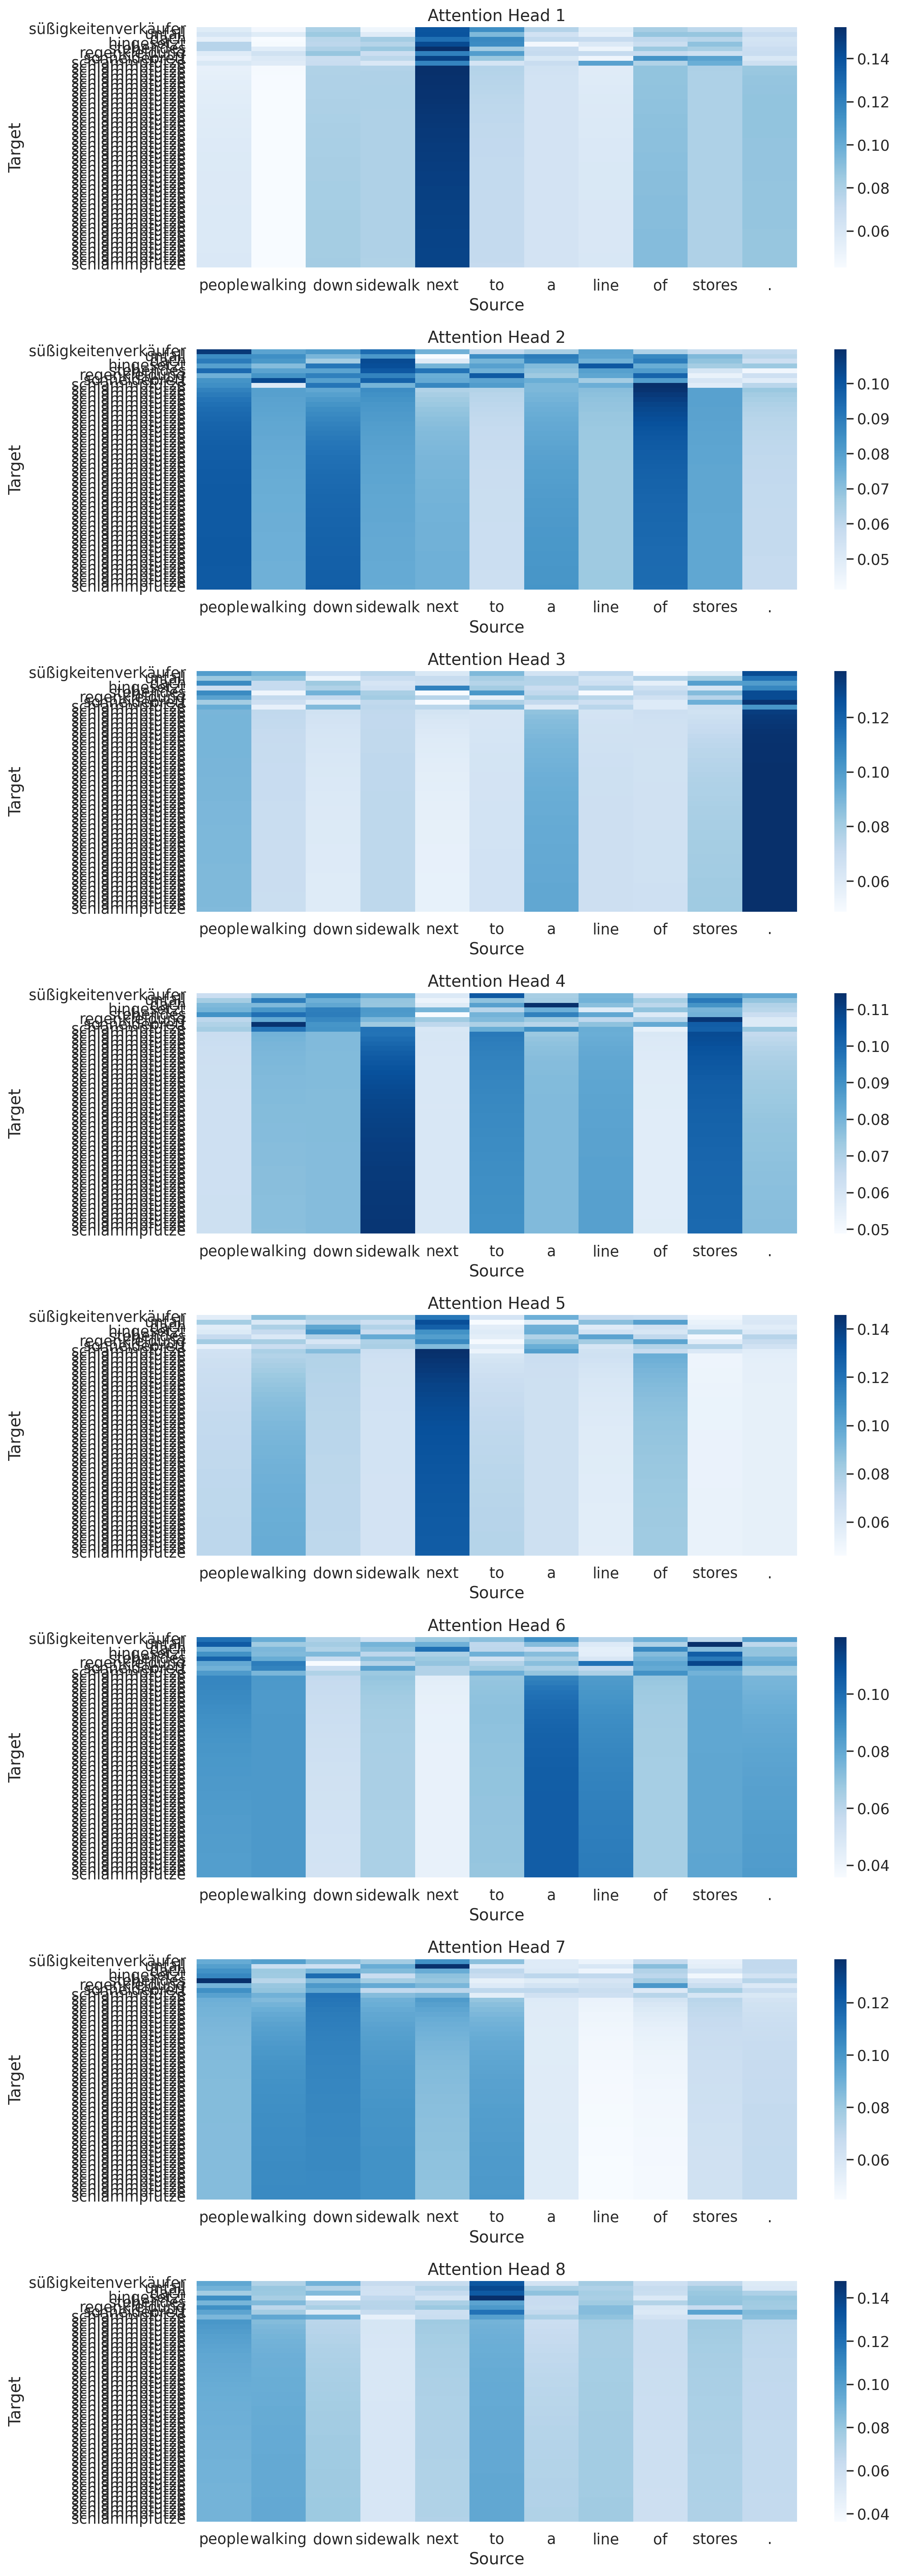

In [117]:
example_idx = 50

source = test_data[example_idx]["en"]
target = test_data[example_idx]["de"]

source_text = " ".join(source) if isinstance(source, list) else source
target_text = " ".join(target) if isinstance(target, list) else target

predicted, attention_scores = greedy_decode(
    model,
    source_text
)

print("\n" + "=" * 70)
print("TRANSLATION RESULT")
print("=" * 70)
print("Source    :", source_text)
print("Target    :", target_text)
print("Predicted :", " ".join(predicted))
print("=" * 70)

# Show attention as a diagram
if attention_scores:
    plot_attention_scores(
        source_text,
        predicted,
        attention_scores
    )
else:
    print("\nNo attention scores were returned.")

## References

1. [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
2. [Łukasz Kaiser’s talk on Attentional Neural Network](https://www.youtube.com/watch?v=rBCqOTEfxvg)
3. [The Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)
4. [The Annotated Transformer by Harvard NLP Group](https://nlp.seas.harvard.edu/2018/04/03/attention.html)
5. [Attention is all you need: A Pytorch Implementation by @jadore801120](https://github.com/jadore801120/attention-is-all-you-need-pytorch)
6. [PyTorch Seq2Seq by Ben Trevett](https://github.com/bentrevett/pytorch-seq2seq)
